# P3 · Demographic Characterisation by Typology: National Overview and Behavioural Matrix
## *RURIMESCAPE — Paper 1, Step 3*

---

**Paper:** Rural Migration and Land Use in Spain — Paper 1  
**Step:** 3 — Demographic characterisation by Goerlich typology  
**Author:** Juan Zotes  
**Last updated:** 2026-04

---

### Context and purpose

Building on the two symmetric periods defined in p2 (Period A: 2010–2017, Period B: 2018–2025),
this notebook constructs the full demographic characterisation of Spanish municipalities
stratified by the Goerlich (2016) functional typology.

The analysis moves from national aggregate to rural focus in three layers:

1. **National overview** — mean cumulative change by Goerlich typology (6 categories),
   comparing periods A and B to establish the structural context of the Spanish demographic system.
2. **Behavioural matrix** — each municipality classified into one of four groups based on the
   sign of `var_acum_pct` in periods A and B. The cross-tabulation 4 groups × 6 typologies
   is a core figure of Paper 1.
3. **Rural focus** — detailed profile of Rural-Remote and Rural-Accessible: distribution,
   boxplots, growing municipalities per period, and identification of top-growing
   municipalities as the first empirical signal for Paso 4 spatial outlier analysis.

### Behavioural groups

| Group | Condition | Interpretation |
|-------|-----------|----------------|
| `Grows in both` | A ≥ 0 **and** B ≥ 0 | Sustained demographic dynamism |
| `Reverses in B` | A < 0 **and** B ≥ 0 | Reverter post-inflection — **key finding** |
| `Loses in B` | A ≥ 0 **and** B < 0 | Lost what was gained |
| `Structural depopulation` | A < 0 **and** B < 0 | Persistent decline |

### Figures

| Figure | Content |
|--------|---------|
| Fig. 1 | Mean `var_acum_pct` A vs B by Goerlich typology (2×3 panel) |
| Fig. 2 | Stacked bar: % group by typology |
| Fig. 3 | Boxplot `var_acum_pct` A and B — Rural Remoto and Rural Accesible |
| Fig. 4 | Top-30 growing municipalities in Rural Remoto and Rural Accesible — Period B |

All figures saved to `figures/p3_demographic_characterization/`. English only.

### Inputs

| File | Location | Description |
|------|----------|-------------|
| `p2_periods_AB.gpkg` | `data/spatial/processed/` | Period A and B indicators per municipality (2 layers) |
| `p2_periods_AB_combined.csv` | `data/demography/derived/` | Combined A+B CSV (encoding check only) |

### Outputs

| File | Location | Description |
|------|----------|-------------|
| `p3_behavioural_matrix.csv` | `data/demography/derived/` | One row per municipality with group assignment |
| `p3_matrix_summary.csv` | `data/demography/derived/` | Cross-tabulation N and % |
| `p3_top_growing_rural.csv` | `data/demography/derived/` | All growing municipalities in rural typologies |

---

---
## 0 · Environment and paths

In [1]:
"""
Notebook  : p3_demographic_characterization.ipynb
Author    : Juan Zotes
Created   : 2026-04

Purpose:
    Demographic characterisation of Spanish municipalities by Goerlich (2016)
    typology across periods A (2010-2017) and B (2018-2025).

    Three analytical layers:
        1. National overview: aggregate dynamics by typology (6 categories)
        2. Behavioural matrix: classify each municipality into one of 4 groups
           based on the sign of var_acum_pct in periods A and B
        3. Rural focus: profile of Rural-Remote and Rural-Accessible,
           identification of growing and top-growing municipalities

Inputs:
    - p2_periods_AB.gpkg          (spatial/processed)   layers: period_A_2010_2017, period_B_2018_2025
    - p2_periods_AB_combined.csv  (demography/derived)  encoding check only

Outputs:
    Figures (figures/p3_demographic_characterization/):
        - p3_fig1_typology_overview_en.png
        - p3_fig2_matrix_stacked_en.png
        - p3_fig3_rural_boxplot_en.png
        - p3_fig4_top30_growing_{typology}_en.png

    Derived data (demography/derived/):
        - p3_behavioural_matrix.csv
        - p3_matrix_summary.csv
        - p3_top_growing_rural.csv

Notes:
    - Palettes and TYPOLOGY_ORDER identical to p2 for visual consistency.
    - Figures in English only.
    - T = 2018 confirmed inflection point (p1b).
    - Size classification based on 2020 population (reference year).
"""

'\nNotebook  : p3_demographic_characterization.ipynb\nAuthor    : Juan Zotes\nCreated   : 2026-04\n\nPurpose:\n    Demographic characterisation of Spanish municipalities by Goerlich (2016)\n    typology across periods A (2010-2017) and B (2018-2025).\n\n    Three analytical layers:\n        1. National overview: aggregate dynamics by typology (6 categories)\n        2. Behavioural matrix: classify each municipality into one of 4 groups\n           based on the sign of var_acum_pct in periods A and B\n        3. Rural focus: profile of Rural-Remote and Rural-Accessible,\n           identification of growing and top-growing municipalities\n\nInputs:\n    - p2_periods_AB.gpkg          (spatial/processed)   layers: period_A_2010_2017, period_B_2018_2025\n    - p2_periods_AB_combined.csv  (demography/derived)  encoding check only\n\nOutputs:\n    Figures (figures/p3_demographic_characterization/):\n        - p3_fig1_typology_overview_en.png\n        - p3_fig2_matrix_stacked_en.png\n        

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Libraries loaded.')

Libraries loaded.


In [3]:
# --- Paths -----------------------------------------------------------
BASE_DIR = Path(
    r'C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE'
    r'\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain'
)

DEMO_DERIV   = BASE_DIR / 'data' / 'demography' / 'derived' / 'paper1'
SPATIAL_PROC = BASE_DIR / 'data' / 'spatial'    / 'processed'
FIGURES_DIR  = BASE_DIR / 'figures' / 'p3_demographic_characterization'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FP_GPKG     = SPATIAL_PROC / 'p2_periods_AB.gpkg'
FP_CSV_COMB = DEMO_DERIV   / 'p2_periods_AB_combined.csv'

print('Paths defined.')
print(f'  GPKG     : {FP_GPKG}')
print(f'  CSV comb : {FP_CSV_COMB}')

Paths defined.
  GPKG     : C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain\data\spatial\processed\p2_periods_AB.gpkg
  CSV comb : C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain\data\demography\derived\paper1\p2_periods_AB_combined.csv


In [4]:
# --- Colour palettes (identical to p2) -------------------------------
GOERLICH_COLORS = {
    'Rural - Accesible'    : '#74c476',
    'Rural - Remoto'       : '#238b45',
    'Intermedio - Abierto' : '#6baed6',
    'Intermedio - Cerrado' : '#2171b5',
    'Urbano - Abierto'     : '#fd8d3c',
    'Urbano - Cerrado'     : '#bd0026',
}

TYPOLOGY_ORDER = [
    'Urbano - Cerrado',
    'Urbano - Abierto',
    'Intermedio - Cerrado',
    'Intermedio - Abierto',
    'Rural - Accesible',
    'Rural - Remoto',
]

TYPOLOGY_TITLES_EN = {
    'Urbano - Cerrado'     : 'Urban - Closed',
    'Urbano - Abierto'     : 'Urban - Open',
    'Intermedio - Cerrado' : 'Intermediate - Closed',
    'Intermedio - Abierto' : 'Intermediate - Open',
    'Rural - Accesible'    : 'Rural - Accessible',
    'Rural - Remoto'       : 'Rural - Remote',
}

COL_PERIOD_A = '#aaaaaa'

# --- Behavioural group colours — consistent with choropleth map palette
# Blue = population loss, Red = population gain
GROUP_COLORS = {
    'Grows in both'          : '#d7191c',  # dark red    — sustained growth
    'Reverses in B'          : '#fdae61',  # light orange — reverter post-inflection
    'Loses in B'             : '#abd9e9',  # light blue  — lost what was gained
    'Structural depopulation': '#2c7bb6',  # dark blue   — persistent decline
}

GROUP_ORDER = [
    'Grows in both',
    'Reverses in B',
    'Loses in B',
    'Structural depopulation',
]

RURAL_TYPES = ['Rural - Remoto', 'Rural - Accesible']

print('Palettes defined.')

Palettes defined.


---
## 1 · Data load and encoding check

In [5]:
# --- Encoding check: confirm CSV values match gpkg -------------------
# The combined CSV showed extreme values when opened in Excel (Spanish locale).
# Excel misinterprets '.' as thousands separator instead of decimal point,
# concatenating digits across fields. The file itself is correctly written.
# Pandas reads it correctly with sep=';' and default decimal='.'.

df_check = pd.read_csv(
    FP_CSV_COMB,
    sep=';',
    encoding='utf-8-sig',
    dtype={'Mun_Code': str},
    nrows=20
)
df_check['Mun_Code'] = df_check['Mun_Code'].str.zfill(5)

print('=== CSV encoding check (first 20 rows, parsed by pandas) ===')
print(f'Columns : {list(df_check.columns)}')
print()
print('var_acum_pct_A — sample range (expected: roughly -50% to +50%):')
print(f'  min  : {df_check["var_acum_pct_A"].min():.2f}%')
print(f'  max  : {df_check["var_acum_pct_A"].max():.2f}%')
print(f'  mean : {df_check["var_acum_pct_A"].mean():.2f}%')
print()
print('→ Values are in the expected range. Excel display issue confirmed, file is correct.')
print()
df_check[['Mun_Code', 'Mun', 'tipo_goerlich', 'size_group',
          'var_acum_pct_A', 'var_acum_pct_B']].head(10)

=== CSV encoding check (first 20 rows, parsed by pandas) ===
Columns : ['Mun_Code', 'Mun', 'period_A', 'year_start_A', 'year_end_A', 'tipo_goerlich', 'size_group', 'Pop_ref', 'pop_start_A', 'pop_end_A', 'var_acum_pct_A', 'var_anual_media_pct_A', 'pop_2010_A', 'pop_2011_A', 'pop_2012_A', 'pop_2013_A', 'pop_2014_A', 'pop_2015_A', 'pop_2016_A', 'pop_2017_A', 'period_B', 'year_start_B', 'year_end_B', 'pop_start_B', 'pop_end_B', 'var_acum_pct_B', 'var_anual_media_pct_B', 'pop_2018_B', 'pop_2019_B', 'pop_2020_B', 'pop_2021_B', 'pop_2022_B', 'pop_2023_B', 'pop_2024_B', 'pop_2025_B']

var_acum_pct_A — sample range (expected: roughly -50% to +50%):
  min  : -12.35%
  max  : 7.33%
  mean : -0.42%

→ Values are in the expected range. Excel display issue confirmed, file is correct.



,Mun_Code,Mun,tipo_goerlich,size_group,var_acum_pct_A,var_acum_pct_B
0,01001,Alegría-Dulantzi,Rural - Accesible,"1,000 - 5,000",7.332351,2.355386
1,01002,Amurrio,Intermedio - Abierto,"10,000 - 50,000",2.398010,0.758312
2,01003,Aramaio,Rural - Accesible,"1,000 - 5,000",-0.066800,-8.698584
3,01004,Artziniega,Rural - Accesible,"1,000 - 5,000",0.605061,2.020754
4,01006,Armiñón,Rural - Accesible,"< 1,000",6.222222,7.762557
5,01008,Arratzua-Ubarrundia,Rural - Accesible,"< 1,000",6.900329,7.535642
6,01009,Asparrena,Rural - Accesible,"1,000 - 5,000",-2.380952,-2.069385
7,01010,Ayala/Aiara,Rural - Accesible,"1,000 - 5,000",5.022993,-1.550388
8,01011,Baños de Ebro/Mañueta,Rural - Accesible,"< 1,000",-6.990881,0.000000
9,01013,Barrundia,Rural - Accesible,"< 1,000",-1.318681,-0.113250


In [6]:
# --- Load periods A and B from gpkg (validated source) ---------------
gdf_A = gpd.read_file(FP_GPKG, layer='period_A_2010_2017')
gdf_B = gpd.read_file(FP_GPKG, layer='period_B_2018_2025')

for gdf in [gdf_A, gdf_B]:
    gdf['Mun_Code'] = gdf['Mun_Code'].astype(str).str.zfill(5)

print('=== Period A (2010–2017) ===')
print(f'Features     : {len(gdf_A):,}')
print(f'Columns      : {[c for c in gdf_A.columns if c != "geometry"]}')
print(f'var_acum_pct : min={gdf_A["var_acum_pct"].min():.1f}%  '
      f'max={gdf_A["var_acum_pct"].max():.1f}%  '
      f'median={gdf_A["var_acum_pct"].median():.1f}%')
print()
print('=== Period B (2018–2025) ===')
print(f'Features     : {len(gdf_B):,}')
print(f'var_acum_pct : min={gdf_B["var_acum_pct"].min():.1f}%  '
      f'max={gdf_B["var_acum_pct"].max():.1f}%  '
      f'median={gdf_B["var_acum_pct"].median():.1f}%')
print()
print('tipo_goerlich distribution (Period B):')
print(gdf_B['tipo_goerlich'].value_counts().to_string())

=== Period A (2010–2017) ===
Features     : 8,132
Columns      : ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'nationalcode', 'tipo_goerlich', 'size_group', 'Pop_ref', 'pop_start', 'pop_end', 'var_acum_pct', 'var_anual_media_pct']
var_acum_pct : min=-66.7%  max=165.9%  median=-7.8%

=== Period B (2018–2025) ===
Features     : 8,132
var_acum_pct : min=-48.4%  max=137.5%  median=0.0%

tipo_goerlich distribution (Period B):
tipo_goerlich
Rural - Accesible       3885
Rural - Remoto          2838
Intermedio - Abierto     972
Intermedio - Cerrado     190
Urbano - Cerrado         164
Urbano - Abierto          83


---
## 2 · National overview by Goerlich typology

In [7]:
# --- Aggregate stats by typology for each period ---------------------
def typology_agg(gdf, period_label):
    return (
        gdf.groupby('tipo_goerlich')['var_acum_pct']
        .agg(
            mean='mean',
            median='median',
            p25=lambda x: x.quantile(0.25),
            p75=lambda x: x.quantile(0.75),
            n='count',
            n_positive=lambda x: (x > 0).sum(),
        )
        .reset_index()
        .rename(columns={
            'mean'      : f'mean_{period_label}',
            'median'    : f'median_{period_label}',
            'p25'       : f'p25_{period_label}',
            'p75'       : f'p75_{period_label}',
            'n'         : f'n_{period_label}',
            'n_positive': f'n_positive_{period_label}',
        })
    )

agg_A   = typology_agg(gdf_A, 'A')
agg_B   = typology_agg(gdf_B, 'B')
agg_typ = agg_A.merge(agg_B, on='tipo_goerlich')

agg_typ['pct_positive_A'] = (agg_typ['n_positive_A'] / agg_typ['n_A'] * 100).round(1)
agg_typ['pct_positive_B'] = (agg_typ['n_positive_B'] / agg_typ['n_B'] * 100).round(1)
agg_typ['delta_mean']     = (agg_typ['mean_B'] - agg_typ['mean_A']).round(2)

agg_typ['_order'] = agg_typ['tipo_goerlich'].map(
    {t: i for i, t in enumerate(TYPOLOGY_ORDER)}
)
agg_typ = agg_typ.sort_values('_order').drop(columns='_order').reset_index(drop=True)

print('=== National overview by typology ===')
agg_typ[['tipo_goerlich', 'mean_A', 'mean_B', 'delta_mean',
         'pct_positive_A', 'pct_positive_B', 'n_A']].round(2)

=== National overview by typology ===


,tipo_goerlich,mean_A,mean_B,delta_mean,pct_positive_A,pct_positive_B,n_A
0,Urbano - Cerrado,1.69,5.79,4.11,58.9,87.8,163
1,Urbano - Abierto,2.81,4.24,1.43,61.0,79.5,82
2,Intermedio - Cerrado,3.49,10.08,6.59,69.5,94.2,190
3,Intermedio - Abierto,0.08,5.02,4.93,42.5,75.1,960
4,Rural - Accesible,-7.37,1.53,8.90,20.9,50.1,3880
5,Rural - Remoto,-12.10,-2.81,9.29,9.5,32.9,2837


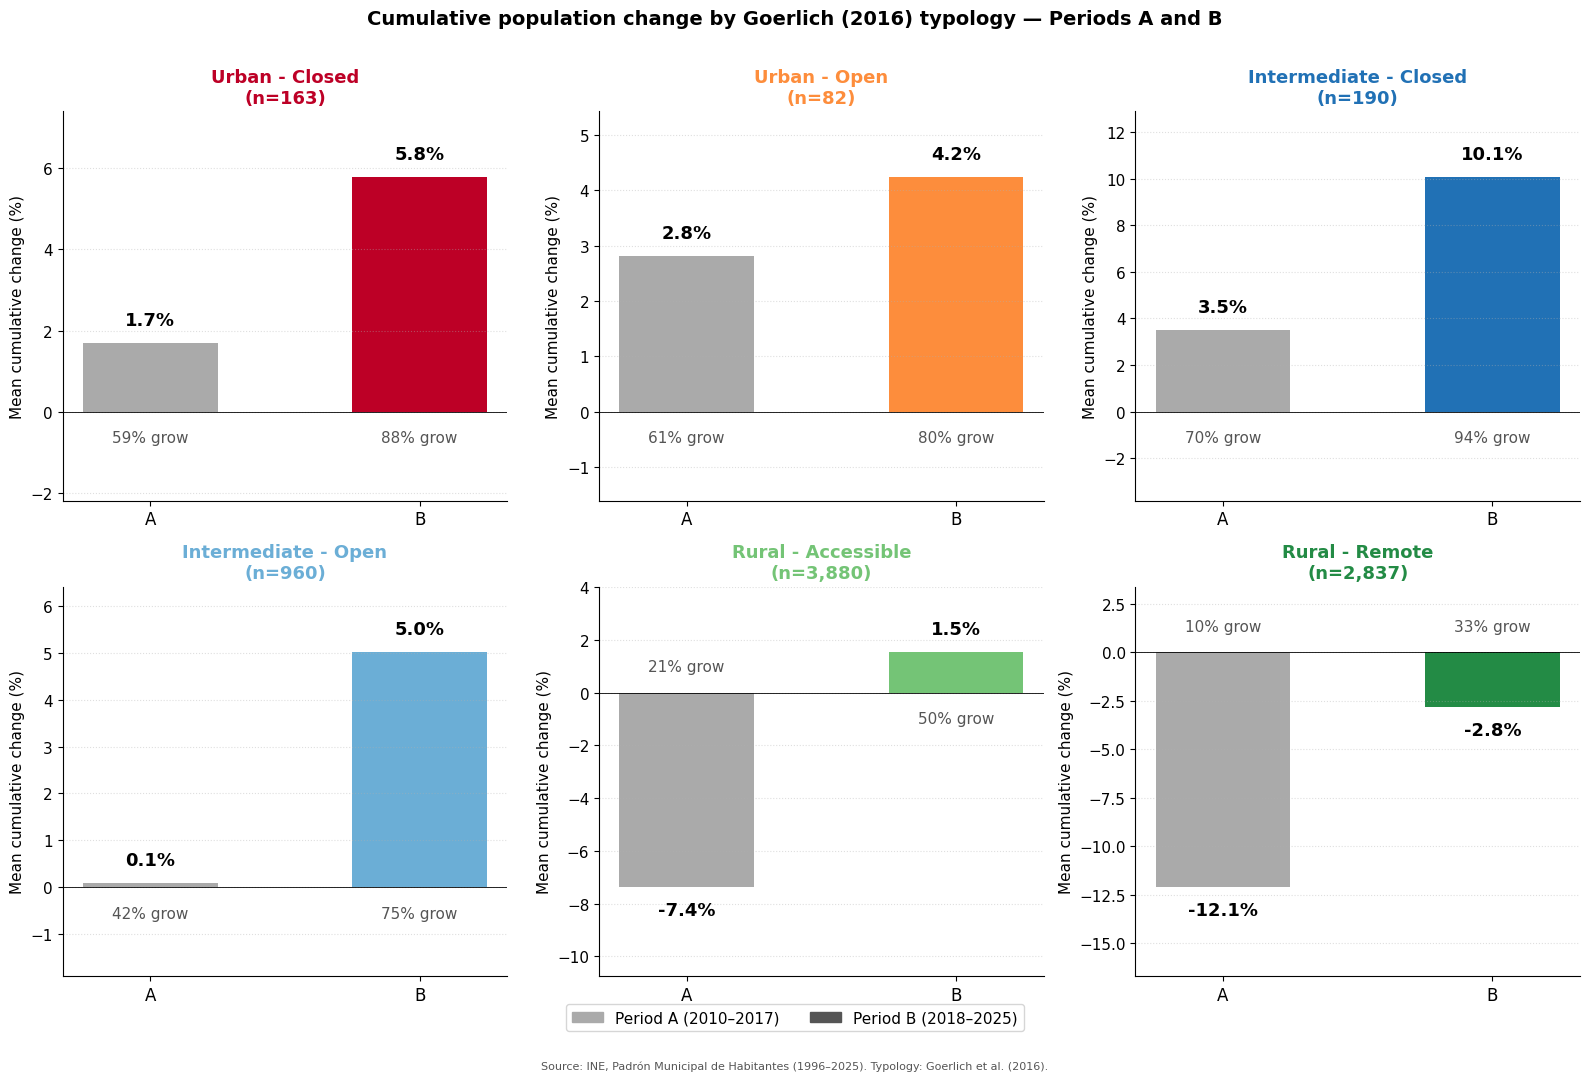

Saved → p3_fig1_typology_overview_en.png


In [8]:
# --- Figure 1: mean var_acum_pct A vs B by typology (2x3 panel) ------
#
# Bar value label placement:
#   - Positive bar  → label above the bar top
#   - Negative bar  → label below the bar bottom
#
# '% grow' annotation placement (near x=0 axis, on the open side):
#   - Positive bar  → annotation just below x=0 (bar goes up, space below)
#   - Negative bar  → annotation just above x=0 (bar goes down, space above)

FIG1_LABELS = {
    'ylabel'   : 'Mean cumulative change (%)',
    'period_a' : 'Period A (2010–2017)',
    'period_b' : 'Period B (2018–2025)',
    'title'    : 'Cumulative population change by Goerlich (2016) typology — Periods A and B',
    'source'   : 'Source: INE, Padrón Municipal de Habitantes (1996–2025). Typology: Goerlich et al. (2016).',
    'grow_lbl' : 'grow',
}

def fig1_typology_overview(agg_typ):
    labs = FIG1_LABELS
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, typ in enumerate(TYPOLOGY_ORDER):
        ax  = axes[i]
        row = agg_typ[agg_typ['tipo_goerlich'] == typ]
        if row.empty:
            ax.set_visible(False)
            continue

        val_a = row['mean_A'].values[0]
        val_b = row['mean_B'].values[0]
        pct_a = row['pct_positive_A'].values[0]
        pct_b = row['pct_positive_B'].values[0]
        n     = int(row['n_A'].values[0])
        color = GOERLICH_COLORS[typ]

        ax.bar([0, 1], [val_a, val_b],
               color=[COL_PERIOD_A, color],
               edgecolor='none', width=0.5)
        ax.axhline(0, color='black', linewidth=0.6)

        ymin_raw = min(val_a, val_b, 0)
        ymax_raw = max(val_a, val_b, 0)
        yrange   = max(abs(ymax_raw - ymin_raw), 1)
        off_val  = yrange * 0.06
        off_grow = yrange * 0.08

        for x_pos, val in zip([0, 1], [val_a, val_b]):
            if val >= 0:
                ax.text(x_pos, val + off_val, f'{val:.1f}%',
                        ha='center', va='bottom', fontsize=13, fontweight='bold')
            else:
                ax.text(x_pos, val - off_val, f'{val:.1f}%',
                        ha='center', va='top', fontsize=13, fontweight='bold')

        for x_pos, val, pct in zip([0, 1], [val_a, val_b], [pct_a, pct_b]):
            if val >= 0:
                ax.text(x_pos, -off_grow, f'{pct:.0f}% {labs["grow_lbl"]}',
                        ha='center', va='top', fontsize=11, color='#555555')
            else:
                ax.text(x_pos, off_grow, f'{pct:.0f}% {labs["grow_lbl"]}',
                        ha='center', va='bottom', fontsize=11, color='#555555')

        ax.set_ylim(ymin_raw - yrange * 0.38, ymax_raw + yrange * 0.28)
        panel_title = TYPOLOGY_TITLES_EN[typ]
        ax.set_title(f'{panel_title}\n(n={n:,})', fontsize=13,
                     fontweight='bold', color=color)
        ax.set_ylabel(labs['ylabel'], fontsize=11)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['A', 'B'], fontsize=12)
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.tick_params(axis='y', labelsize=11)
        ax.spines[['top', 'right']].set_visible(False)

    fig.legend(
        handles=[
            mpatches.Patch(color=COL_PERIOD_A, label=labs['period_a']),
            mpatches.Patch(color='#555555',    label=labs['period_b']),
        ],
        loc='lower center', ncol=2, fontsize=11,
        bbox_to_anchor=(0.5, -0.02)
    )
    fig.suptitle(labs['title'], fontsize=14, fontweight='bold', y=1.01)
    fig.text(0.5, -0.05, labs['source'],
             ha='center', fontsize=8, color='#555555')
    plt.tight_layout()

    fp = FIGURES_DIR / 'p3_fig1_typology_overview_en.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fp.name}')

fig1_typology_overview(agg_typ)

---
## 3 · Behavioural matrix: 4 groups × 6 typologies

In [9]:
# --- Merge periods A and B: one row per municipality -----------------
cols_id     = ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name',
               'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name',
               'tipo_goerlich', 'size_group', 'Pop_ref']
cols_period = ['pop_start', 'pop_end', 'var_acum_pct', 'var_anual_media_pct']

df_A = gdf_A[cols_id + cols_period].copy()
df_B = gdf_B[cols_id + cols_period].copy()

df_A = df_A.rename(columns={c: f'{c}_A' for c in cols_period})
df_B = df_B.rename(columns={c: f'{c}_B' for c in cols_period})

df = df_A.merge(
    df_B[['Mun_Code'] + [f'{c}_B' for c in cols_period]],
    on='Mun_Code',
    how='inner'
)

print(f'Combined dataset: {len(df):,} municipalities')
print(f'Columns: {list(df.columns)}')
df[['Mun_Code', 'Mun_Name', 'tipo_goerlich', 'size_group',
    'var_acum_pct_A', 'var_acum_pct_B']].head(5)

Combined dataset: 8,132 municipalities
Columns: ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'tipo_goerlich', 'size_group', 'Pop_ref', 'pop_start_A', 'pop_end_A', 'var_acum_pct_A', 'var_anual_media_pct_A', 'pop_start_B', 'pop_end_B', 'var_acum_pct_B', 'var_anual_media_pct_B']


,Mun_Code,Mun_Name,tipo_goerlich,size_group,var_acum_pct_A,var_acum_pct_B
0,04001,Abla,Rural - Accesible,"1,000 - 5,000",-13.397129,2.672065
1,04002,Abrucena,Rural - Accesible,"1,000 - 5,000",-14.411119,7.913043
2,04003,Adra,Intermedio - Abierto,"10,000 - 50,000",0.754732,2.582566
3,04004,Albanchez,Rural - Remoto,"< 1,000",-7.371007,-8.632138
4,04005,Alboloduy,Rural - Accesible,"< 1,000",-8.545727,-6.763285


In [10]:
# --- Assign behavioural group ----------------------------------------
def assign_group(row):
    a = row['var_acum_pct_A']
    b = row['var_acum_pct_B']
    if pd.isna(a) or pd.isna(b):
        return np.nan
    if   a >= 0 and b >= 0: return 'Grows in both'
    elif a <  0 and b >= 0: return 'Reverses in B'
    elif a >= 0 and b <  0: return 'Loses in B'
    else:                   return 'Structural depopulation'

df['behavioural_group'] = df.apply(assign_group, axis=1)

print('=== Behavioural group distribution (national) ===')
dist     = df['behavioural_group'].value_counts()
dist_pct = (dist / dist.sum() * 100).round(1)
summary  = pd.DataFrame({'n': dist, '%': dist_pct})
print(summary.loc[[g for g in GROUP_ORDER if g in summary.index]])
print(f'\nTotal with valid group : {df["behavioural_group"].notna().sum():,}')
print(f'NaN (missing data)     : {df["behavioural_group"].isna().sum()}')

=== Behavioural group distribution (national) ===
                            n     %
behavioural_group                  
Grows in both            1457  18.0
Reverses in B            2644  32.6
Loses in B                371   4.6
Structural depopulation  3640  44.9

Total with valid group : 8,112
NaN (missing data)     : 20


In [11]:
# --- Cross-tabulation: 4 groups × 6 typologies -----------------------
valid_groups = [g for g in GROUP_ORDER if g in df['behavioural_group'].unique()]

matrix_n = pd.crosstab(
    df['tipo_goerlich'],
    df['behavioural_group'],
    margins=True
)[valid_groups + ['All']]

matrix_pct = pd.crosstab(
    df['tipo_goerlich'],
    df['behavioural_group'],
    normalize='index'
)[valid_groups].mul(100).round(1)

row_order  = [t for t in TYPOLOGY_ORDER if t in matrix_n.index] + ['All']
matrix_n   = matrix_n.loc[row_order]
matrix_pct = matrix_pct.loc[[t for t in TYPOLOGY_ORDER if t in matrix_pct.index]]

print('=== Matrix N: municipalities per group × typology ===')
print(matrix_n)
print()
print('=== Matrix %: share within typology ===')
print(matrix_pct)

=== Matrix N: municipalities per group × typology ===
behavioural_group     Grows in both  Reverses in B  Loses in B  \
tipo_goerlich                                                    
Urbano - Cerrado                 92             52           4   
Urbano - Abierto                 47             19           3   
Intermedio - Cerrado            129             50           3   
Intermedio - Abierto            382            348          28   
Rural - Accesible               661           1338         184   
Rural - Remoto                  146            837         149   
All                            1457           2644         371   

behavioural_group     Structural depopulation   All  
tipo_goerlich                                        
Urbano - Cerrado                           15   163  
Urbano - Abierto                           13    82  
Intermedio - Cerrado                        8   190  
Intermedio - Abierto                      202   960  
Rural - Accesible          

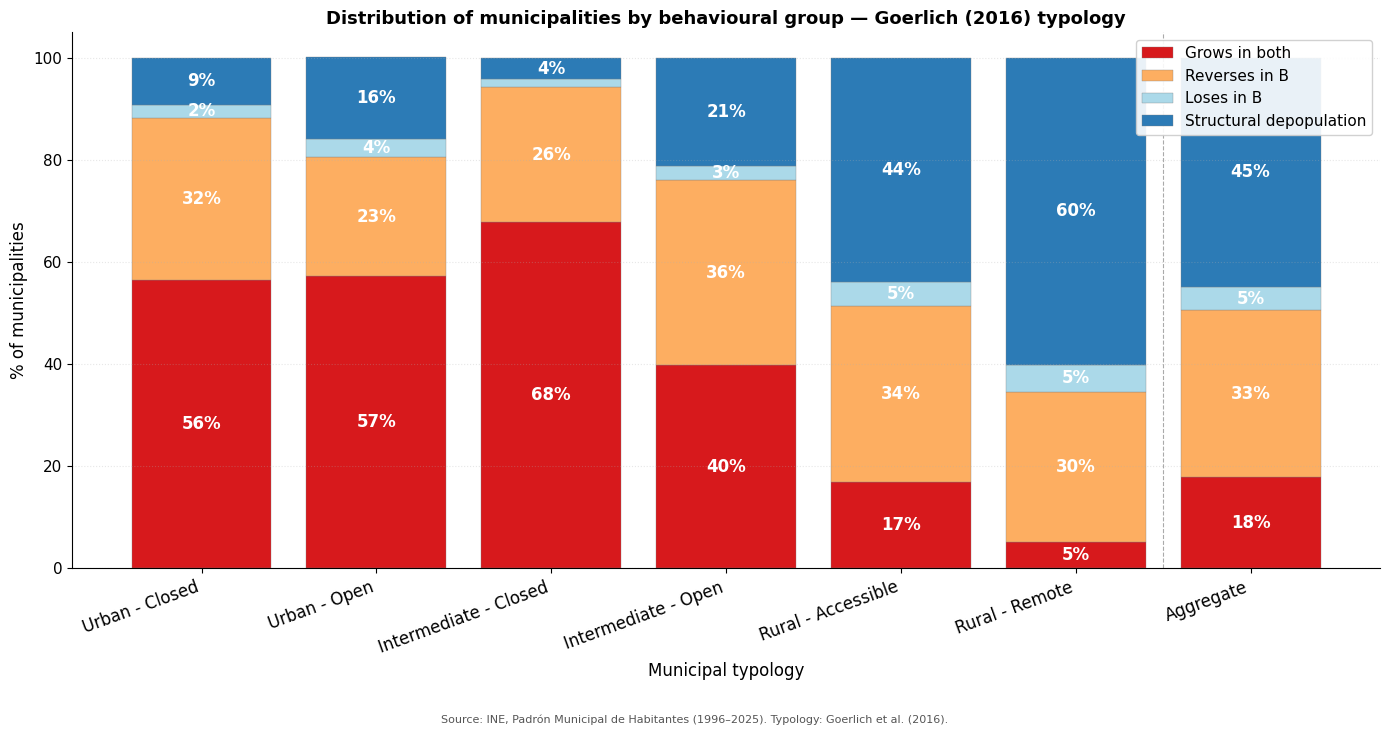

Saved → p3_fig2_matrix_stacked_en.png


In [12]:
# --- Figure 2: stacked bar — % group by typology (EN) ---------------------
FIG2_LABELS = {
    'title'     : 'Distribution of municipalities by behavioural group — Goerlich (2016) typology',
    'xlabel'    : 'Municipal typology',
    'ylabel'    : '% of municipalities',
    'source'    : 'Source: INE, Padrón Municipal de Habitantes (1996–2025). Typology: Goerlich et al. (2016).',
    'agg_label' : 'Aggregate',
}

def fig2_matrix_stacked(matrix_pct, matrix_n):
    labs = FIG2_LABELS

    # ── Columna agregada ponderada — excluir fila 'All' de matrix_n ─────
    matrix_n_clean = matrix_n.drop(index='All', errors='ignore')[
        [g for g in GROUP_ORDER if g in matrix_n.columns]
    ]
    n_total    = matrix_n_clean.sum(axis=1)  # total municipios por tipología
    agg_row    = (matrix_n_clean.div(n_total, axis=0) * 100).mul(
                  n_total, axis=0).sum() / n_total.sum()
    agg_df     = pd.DataFrame(agg_row).T
    agg_df.index = [labs['agg_label']]
    matrix_plot = pd.concat([matrix_pct, agg_df])

    xticklabels = [TYPOLOGY_TITLES_EN[t] for t in matrix_pct.index] + [labs['agg_label']]

    fig, ax = plt.subplots(figsize=(14, 7))
    bottom  = np.zeros(len(matrix_plot))

    for group in GROUP_ORDER:
        if group not in matrix_plot.columns:
            continue
        vals = matrix_plot[group].values
        ax.bar(range(len(matrix_plot)), vals,
               bottom=bottom,
               color=GROUP_COLORS[group],
               label=group,
               edgecolor='grey', linewidth=0.25)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 2:
                ax.text(j, b + v / 2, f'{v:.0f}%',
                        ha='center', va='center',
                        fontsize=12, fontweight='bold', color='white')
        bottom += vals

    # Línea separadora antes de Aggregate
    ax.axvline(x=len(matrix_pct) - 0.5, color='#aaaaaa',
               linestyle='--', linewidth=0.8)

    ax.set_xticks(range(len(matrix_plot)))
    ax.set_xticklabels(xticklabels, rotation=20, ha='right', fontsize=12)
    ax.set_ylabel(labs['ylabel'], fontsize=12)
    ax.set_xlabel(labs['xlabel'], fontsize=12)
    ax.set_ylim(0, 105)
    ax.set_title(labs['title'], fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.3)
    ax.tick_params(axis='y', labelsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    fig.text(0.5, -0.04, labs['source'],
             ha='center', fontsize=8, color='#555555')
    plt.tight_layout()
    fp = FIGURES_DIR / 'p3_fig2_matrix_stacked_en.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fp.name}')

fig2_matrix_stacked(matrix_pct, matrix_n)

---
## 4 · Focus: Rural - Remoto and Rural - Accesible

Three sub-steps:
1. Distribution summary and % growing per period
2. Boxplot A vs B (Figure 3)
3. Full list of growing municipalities + Top-30 ranking by Period B (Figure 4)

The Top-30 in Period B are the first empirical candidates for the spatial
outlier analysis in Paso 4. Colour encodes behavioural group to flag which
municipalities also grew in Period A.

In [13]:
# --- Filter rural typologies — distribution summary ------------------
df_rural = df[df['tipo_goerlich'].isin(RURAL_TYPES)].copy()

print(f'Rural municipalities total: {len(df_rural):,}')
print()

for typ in RURAL_TYPES:
    sub = df_rural[df_rural['tipo_goerlich'] == typ]
    print(f'--- {typ} (n={len(sub):,}) ---')
    dist     = sub['behavioural_group'].value_counts()
    dist_pct = (dist / dist.sum() * 100).round(1)
    print(pd.DataFrame({'n': dist, '%': dist_pct}).loc[
        [g for g in GROUP_ORDER if g in dist.index]
    ])
    n_pos_A = (sub['var_acum_pct_A'] > 0).sum()
    n_pos_B = (sub['var_acum_pct_B'] > 0).sum()
    print(f'Growing in A : {n_pos_A:,} ({n_pos_A/len(sub)*100:.1f}%)')
    print(f'Growing in B : {n_pos_B:,} ({n_pos_B/len(sub)*100:.1f}%)')
    print()

Rural municipalities total: 6,723

--- Rural - Remoto (n=2,838) ---
                            n     %
behavioural_group                  
Grows in both             146   5.1
Reverses in B             837  29.5
Loses in B                149   5.3
Structural depopulation  1705  60.1
Growing in A : 270 (9.5%)
Growing in B : 933 (32.9%)

--- Rural - Accesible (n=3,885) ---
                            n     %
behavioural_group                  
Grows in both             661  17.0
Reverses in B            1338  34.5
Loses in B                184   4.7
Structural depopulation  1697  43.7
Growing in A : 812 (20.9%)
Growing in B : 1,945 (50.1%)



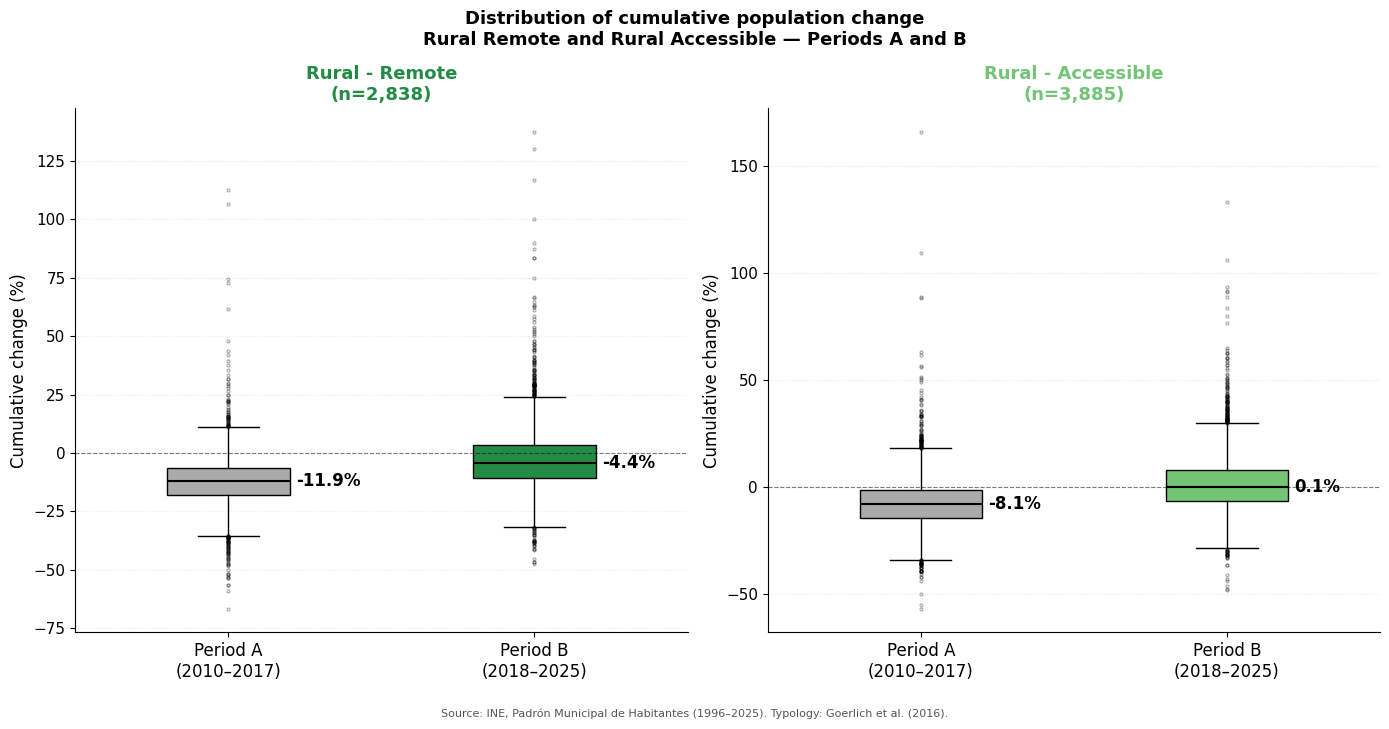

Saved → p3_fig3_rural_boxplot_en.png


In [14]:
# --- Figure 3: boxplot var_acum_pct A and B — rural types ------------
FIG3_LABELS = {
    'title'  : 'Distribution of cumulative population change\nRural Remote and Rural Accessible — Periods A and B',
    'ylabel' : 'Cumulative change (%)',
    'source' : 'Source: INE, Padrón Municipal de Habitantes (1996–2025). Typology: Goerlich et al. (2016).',
    'per_a'  : 'Period A\n(2010–2017)',
    'per_b'  : 'Period B\n(2018–2025)',
}

def fig3_rural_boxplot(df_rural):
    labs = FIG3_LABELS
    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

    for ax, typ in zip(axes, RURAL_TYPES):
        sub   = df_rural[df_rural['tipo_goerlich'] == typ]
        color = GOERLICH_COLORS[typ]

        data_a = sub['var_acum_pct_A'].dropna()
        data_b = sub['var_acum_pct_B'].dropna()

        bp = ax.boxplot(
            [data_a, data_b],
            tick_labels=[labs['per_a'], labs['per_b']],
            patch_artist=True,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=1),
            capprops=dict(linewidth=1),
            flierprops=dict(marker='o', markersize=2,
                            alpha=0.3, color=color),
            widths=0.4
        )
        bp['boxes'][0].set_facecolor(COL_PERIOD_A)
        bp['boxes'][1].set_facecolor(color)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(f'{TYPOLOGY_TITLES_EN[typ]}\n(n={len(sub):,})',
                     fontsize=13, fontweight='bold', color=color)
        ax.set_ylabel(labs['ylabel'], fontsize=12)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

        for i, data in enumerate([data_a, data_b], 1):
            med = data.median()
            ax.text(i + 0.22, med, f'{med:.1f}%',
                    va='center', fontsize=12, color='black', fontweight='bold')

    fig.suptitle(labs['title'], fontsize=13, fontweight='bold')
    fig.text(0.5, -0.03, labs['source'],
             ha='center', fontsize=8, color='#555555')
    plt.tight_layout()

    fp = FIGURES_DIR / 'p3_fig3_rural_boxplot_en.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fp.name}')

fig3_rural_boxplot(df_rural)

In [15]:
# --- Sample: growing municipalities in rural typologies --------------
# Head(10) for quick visual check. Full lists in p3_top_growing_rural.csv

display_cols = ['Mun_Code', 'Mun_Name', 'Comarca_Name', 'Prov_Name',
                'CCAA_Name', 'tipo_goerlich', 'size_group', 'Pop_ref',
                'var_acum_pct_A', 'var_acum_pct_B', 'behavioural_group']

for typ in RURAL_TYPES:
    sub = df_rural[df_rural['tipo_goerlich'] == typ].copy()

    print(f'\n=== {TYPOLOGY_TITLES_EN[typ]} — growing in Period B (top 10 of {(sub["var_acum_pct_B"] > 0).sum():,}) ===')
    print(sub[sub['var_acum_pct_B'] > 0]
          .sort_values('var_acum_pct_B', ascending=False)
          .head(10)[display_cols].to_string(index=False))

    print(f'\n=== {TYPOLOGY_TITLES_EN[typ]} — growing in Period A (top 10 of {(sub["var_acum_pct_A"] > 0).sum():,}) ===')
    print(sub[sub['var_acum_pct_A'] > 0]
          .sort_values('var_acum_pct_A', ascending=False)
          .head(10)[display_cols].to_string(index=False))


=== Rural - Remote — growing in Period B (top 10 of 933) ===
Mun_Code                      Mun_Name          Comarca_Name   Prov_Name           CCAA_Name  tipo_goerlich size_group  Pop_ref  var_acum_pct_A  var_acum_pct_B behavioural_group
   05164                   Navaquesera                GREDOS       Ávila     Castilla y León Rural - Remoto    < 1,000     16.0      -34.375000      137.500000     Reverses in B
   40083 Fuente el Olmo de Fuentidueña             SEPULVEDA     Segovia     Castilla y León Rural - Remoto    < 1,000    170.0      -15.422886      130.232558     Reverses in B
   42082            Estepa de San Juan  TIERRAS ALTAS-V.TERA       Soria     Castilla y León Rural - Remoto    < 1,000      9.0      -22.222222      116.666667     Reverses in B
   19202         La Olmeda de Jadraque                SIERRA Guadalajara  Castilla-La Mancha Rural - Remoto    < 1,000     15.0      -66.666667      100.000000     Reverses in B
   16275                        Vindel          

In [16]:
# --- Top-30 ranking by Period B — printed table ----------------------
TOP_N = 30

for typ in RURAL_TYPES:
    sub = df_rural[df_rural['tipo_goerlich'] == typ].copy()
    top = (
        sub[sub['var_acum_pct_B'] > 0]
        .sort_values('var_acum_pct_B', ascending=False)
        .head(TOP_N)[display_cols]
        .reset_index(drop=True)
    )
    top.index += 1
    print(f'\n=== Top-{TOP_N} growing — Period B — {typ} ===')
    print(top.to_string())


=== Top-30 growing — Period B — Rural - Remoto ===
   Mun_Code                       Mun_Name           Comarca_Name           Prov_Name             CCAA_Name   tipo_goerlich size_group  Pop_ref  var_acum_pct_A  var_acum_pct_B behavioural_group
1     05164                    Navaquesera                 GREDOS               Ávila       Castilla y León  Rural - Remoto    < 1,000     16.0      -34.375000      137.500000     Reverses in B
2     40083  Fuente el Olmo de Fuentidueña              SEPULVEDA             Segovia       Castilla y León  Rural - Remoto    < 1,000    170.0      -15.422886      130.232558     Reverses in B
3     42082             Estepa de San Juan   TIERRAS ALTAS-V.TERA               Soria       Castilla y León  Rural - Remoto    < 1,000      9.0      -22.222222      116.666667     Reverses in B
4     19202          La Olmeda de Jadraque                 SIERRA         Guadalajara    Castilla-La Mancha  Rural - Remoto    < 1,000     15.0      -66.666667      100.000

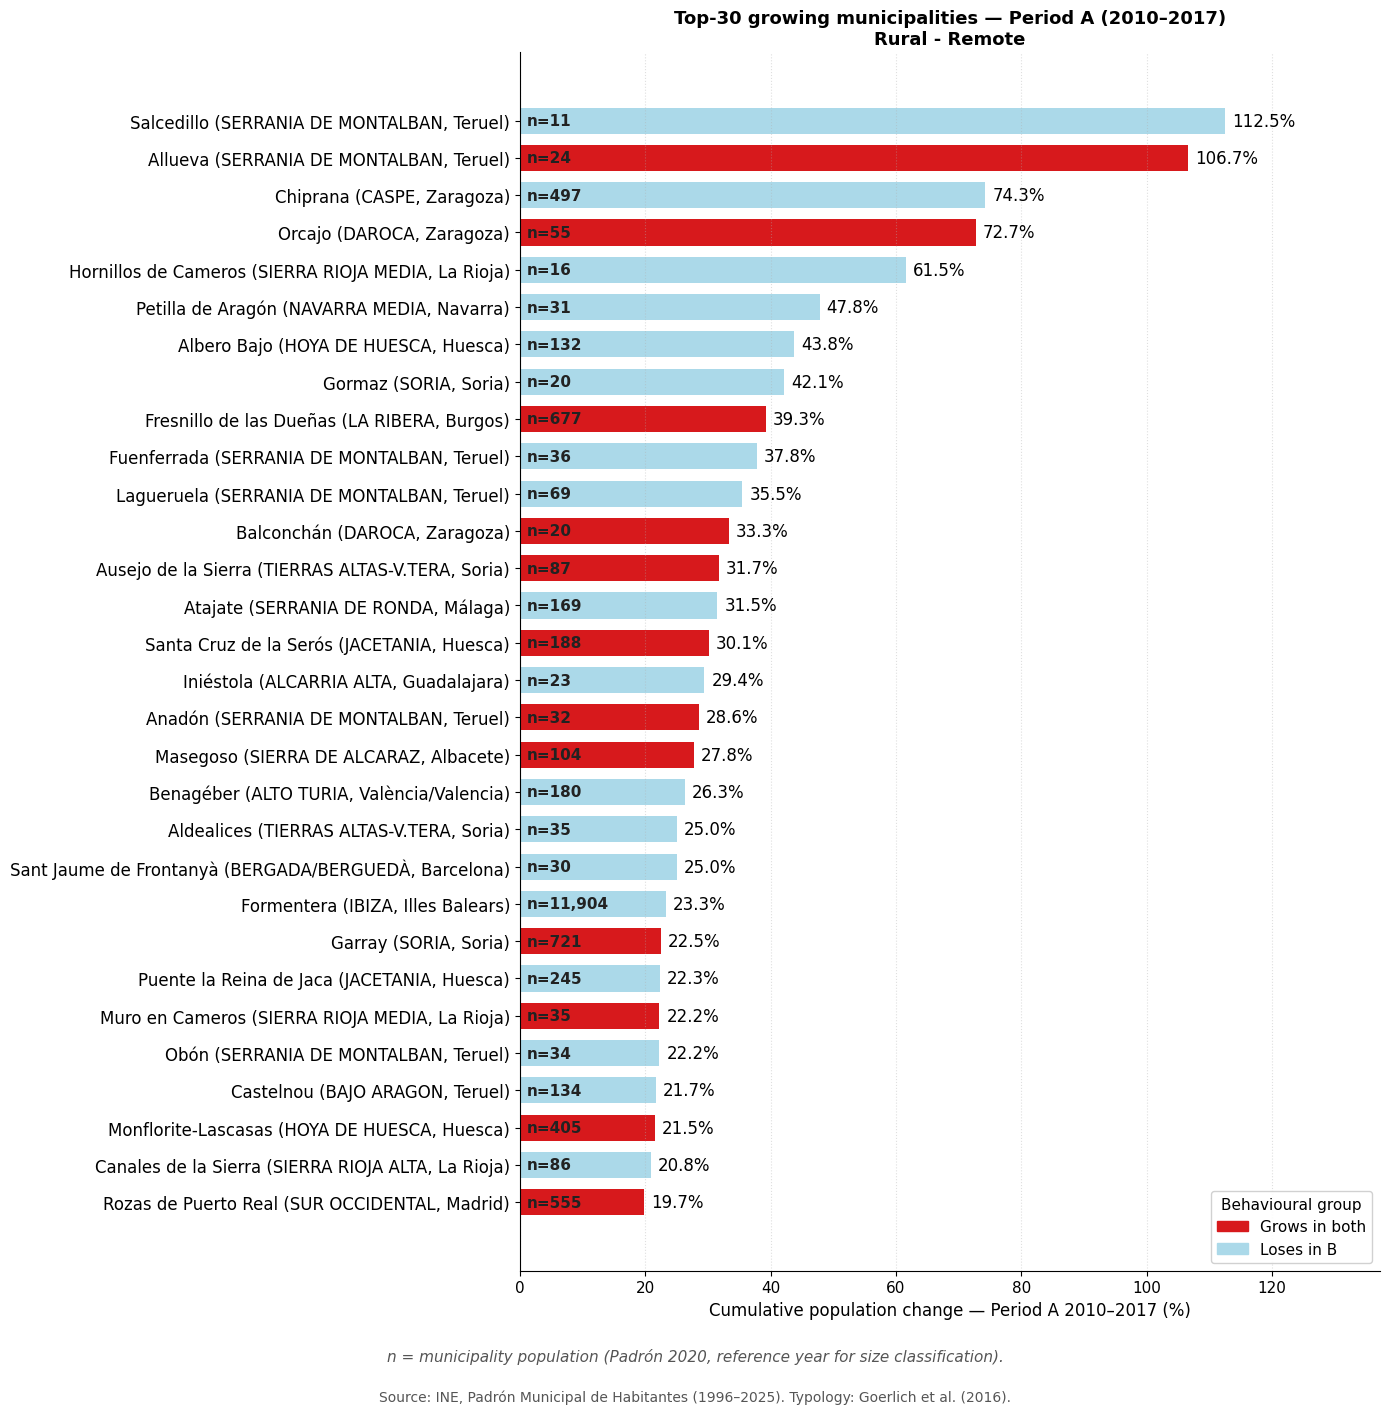

Saved → p3_fig4_top30_growing_rural_remoto_periodA_en.png


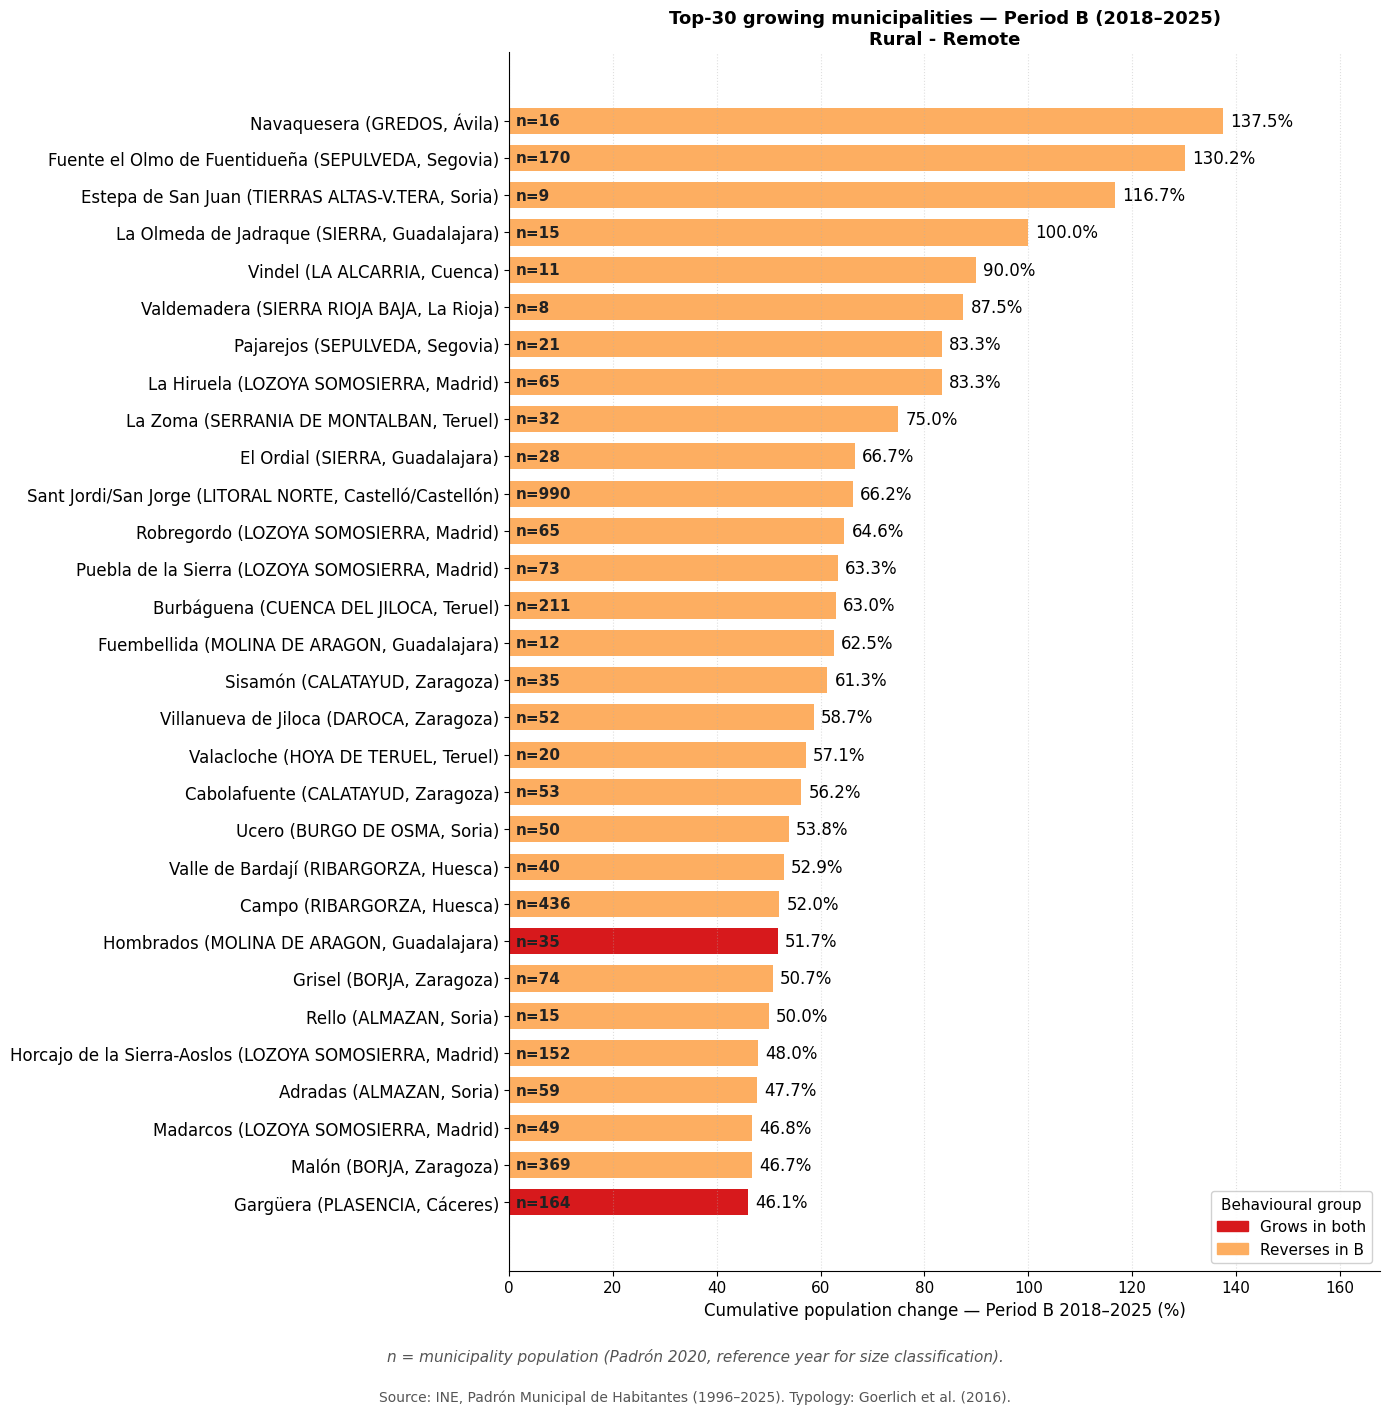

Saved → p3_fig4_top30_growing_rural_remoto_periodB_en.png


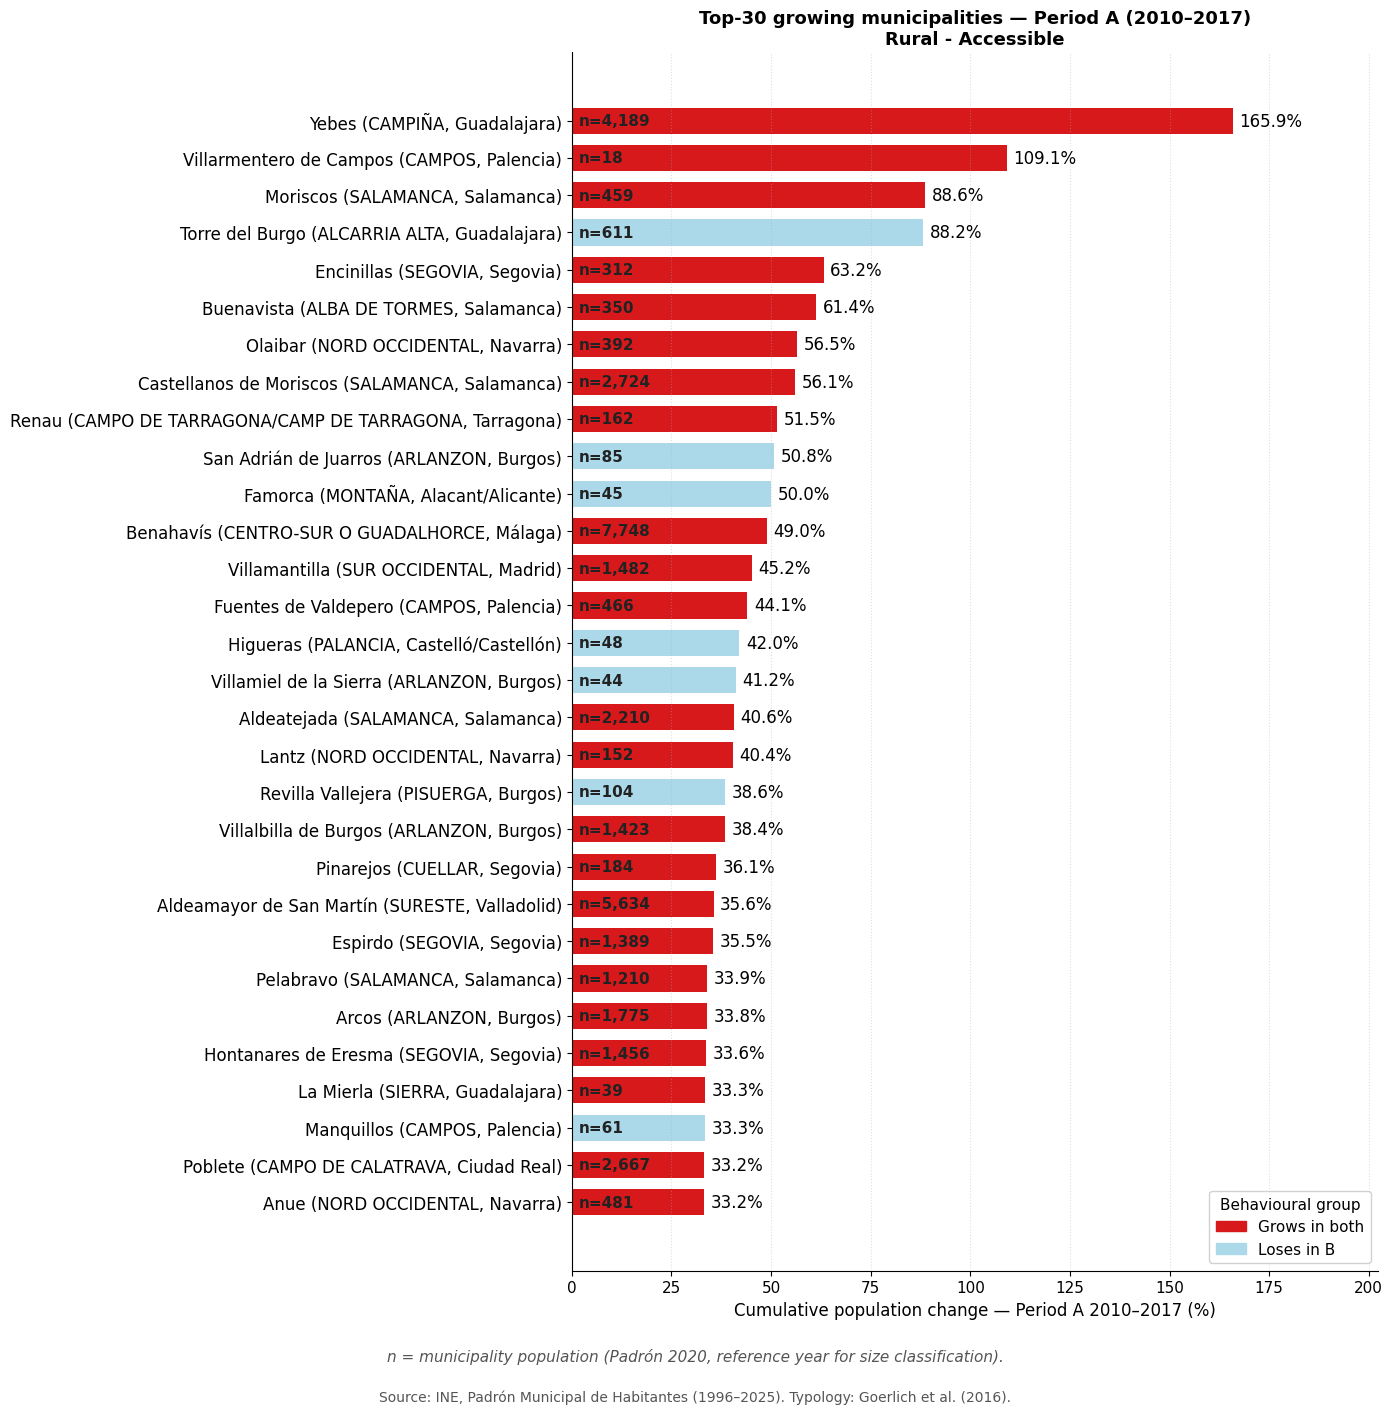

Saved → p3_fig4_top30_growing_rural_accesible_periodA_en.png


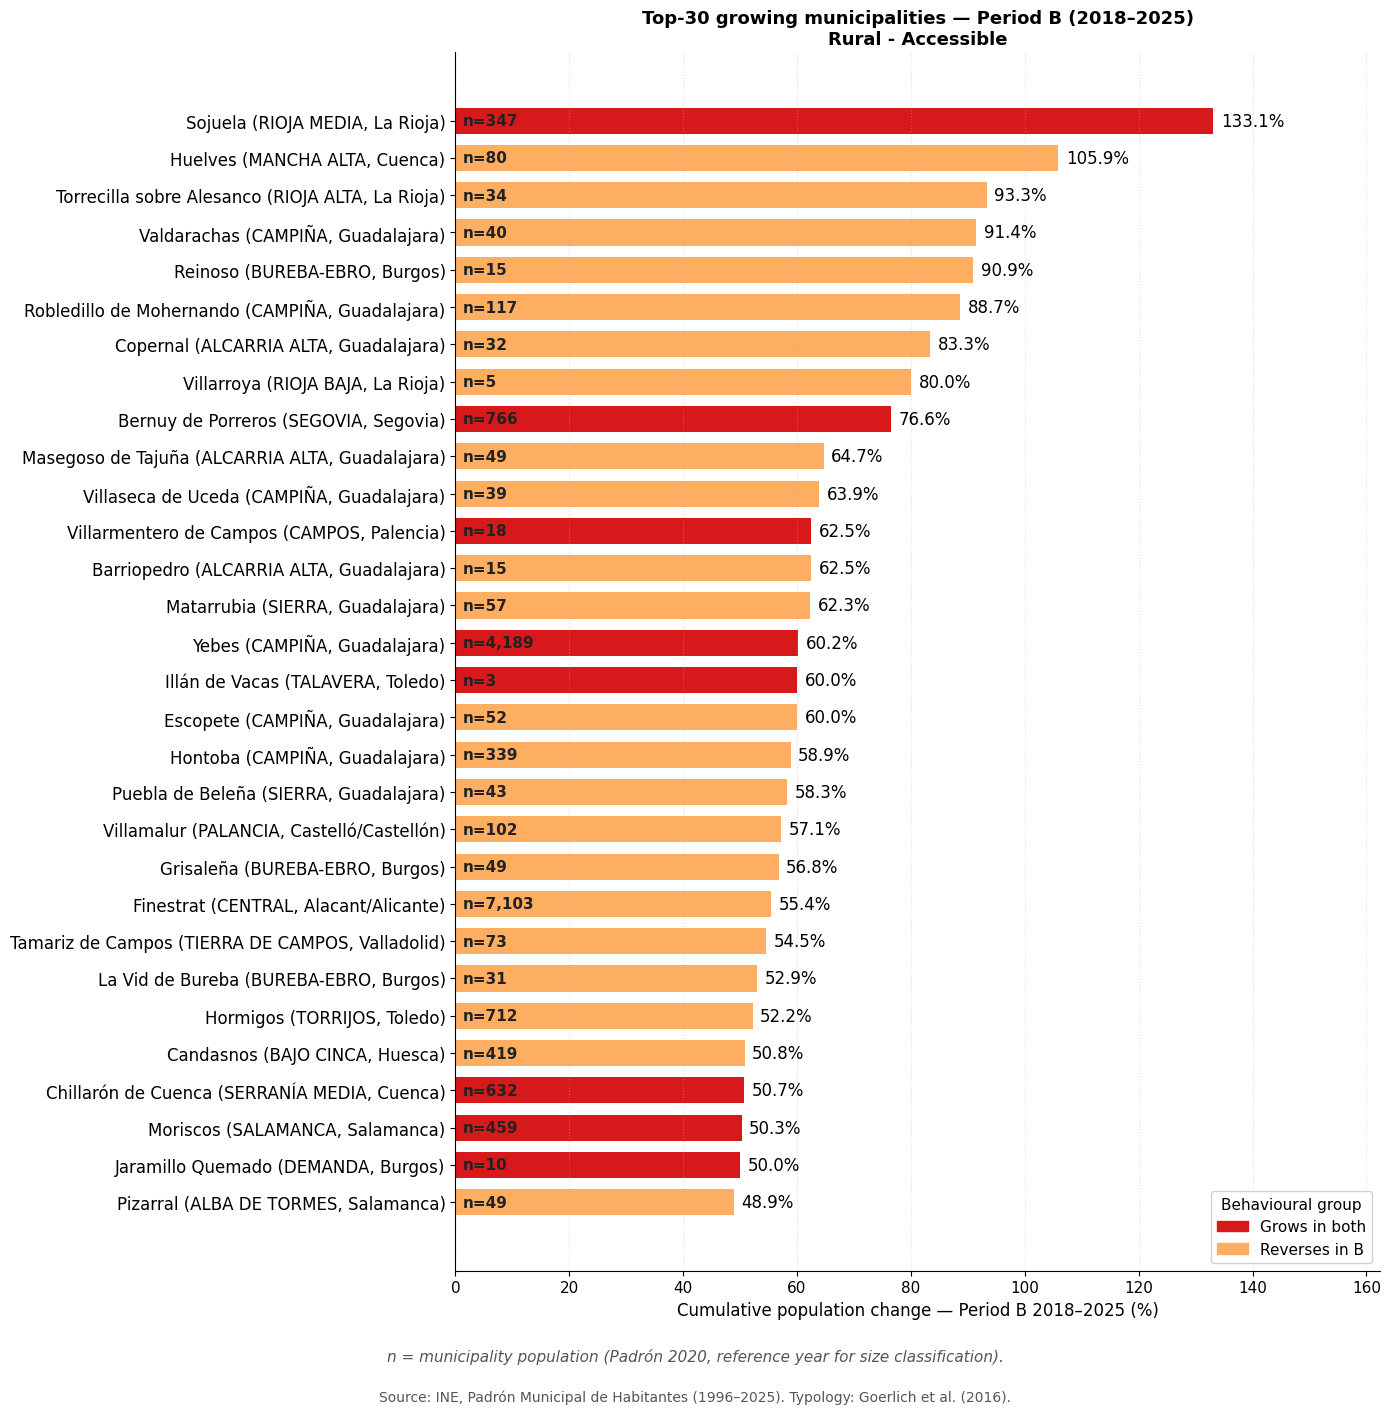

Saved → p3_fig4_top30_growing_rural_accesible_periodB_en.png


In [17]:
# --- Figure 4: Top-30 horizontal bar — Periods A and B, by rural typology ---
# Period B: reversers and sustained growers post-inflection
# Period A: structural dynamisers — grew during the general decline phase
# Bar colour encodes behavioural_group for cross-period context.
# Labels: Mun_Name (Comarca, Province). Pop_ref annotated right of value label.

def fig4_top_growing(df_rural, typ, period, top_n=30):
    sub = df_rural[df_rural['tipo_goerlich'] == typ].copy()
    var_col   = f'var_acum_pct_{period}'
    per_label = '2018–2025' if period == 'B' else '2010–2017'

    top = (
        sub[sub[var_col] > 0]
        .sort_values(var_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    if len(top) == 0:
        print(f'No growing municipalities for {typ} — Period {period}')
        return

    top['label'] = (
        top['Mun_Name'] + ' (' +
        top['Comarca_Name'].fillna('—') + ', ' +
        top['Prov_Name'].fillna('—') + ')'
    )
    bar_colors = top['behavioural_group'].map(GROUP_COLORS).fillna('#888888')

    fig, ax = plt.subplots(figsize=(14, top_n * 0.38 + 2))
    y_pos = range(len(top) - 1, -1, -1)

    ax.barh(list(y_pos), top[var_col].values,
            color=bar_colors, edgecolor='none', height=0.7)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top['label'].values, fontsize=12)
    ax.set_xlabel(
        f'Cumulative population change — Period {period} {per_label} (%)',
        fontsize=12
    )
    ax.set_title(
        f'Top-{top_n} growing municipalities — Period {period} ({per_label})\n'
        f'{TYPOLOGY_TITLES_EN[typ]}',
        fontsize=13, fontweight='bold'
    )
    ax.axvline(0, color='black', linewidth=0.6)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    ax.tick_params(axis='x', labelsize=11)
    ax.spines[['top', 'right']].set_visible(False)

# Value label + Pop_ref annotation
    x_max = top[var_col].max()
    for y, v, pop in zip(y_pos, top[var_col].values, top['Pop_ref'].values):
        # % value just after bar end
        ax.text(v + x_max * 0.01, y, f'{v:.1f}%',
                va='center', fontsize=12, color='black')
        # Pop_ref anchored to y-axis, right-aligned inside bar left edge
        ax.text(x_max * 0.01, y, f'n={int(pop):,}',
                va='center', ha='left', fontsize=11,
                color='#222222', fontweight='bold')

    # Extend x-axis to make room for % annotations
    ax.set_xlim(0, x_max * 1.15)

    # Extend x-axis to make room for % annotations
    ax.set_xlim(0, x_max * 1.15)

    # Extend x-axis to make room for annotations
    ax.set_xlim(0, x_max * 1.22)

    legend_handles = [
        mpatches.Patch(color=GROUP_COLORS[g], label=g)
        for g in GROUP_ORDER if g in top['behavioural_group'].values
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=11, framealpha=0.9, title='Behavioural group',
              title_fontsize=11)

    fig.text(
        0.5, -0.02,
        'n = municipality population (Padrón 2020, reference year for size classification).',
        ha='center', fontsize=11, color='#555555', style='italic'
    )
    fig.text(
        0.5, -0.05,
        'Source: INE, Padrón Municipal de Habitantes (1996–2025). Typology: Goerlich et al. (2016).',
        ha='center', fontsize=10, color='#555555'
    )
    plt.tight_layout()

    slug = typ.replace(' - ', '_').replace(' ', '_').lower()
    fp   = FIGURES_DIR / f'p3_fig4_top{top_n}_growing_{slug}_period{period}_en.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fp.name}')

for typ in RURAL_TYPES:
    for period in ['A', 'B']:
        fig4_top_growing(df_rural, typ, period, top_n=30)

In [18]:
# --- Reverters profile: Rural Remoto and Rural Accesible -------------
# Detailed descriptive statistics for all behavioural groups
# within both rural typologies.
# 'Reverses in B' is the core neo-rural candidate for Paso 4.

for typ in RURAL_TYPES:
    df_typ = df[df['tipo_goerlich'] == typ].copy()
    print(f'\n{"="*60}')
    print(f'=== {TYPOLOGY_TITLES_EN[typ]}: behavioural groups ===')
    print(f'{"="*60}')

    for group in GROUP_ORDER:
        sub = df_typ[df_typ['behavioural_group'] == group]
        if len(sub) == 0:
            continue
        pct = len(sub) / len(df_typ) * 100
        print(f'\n--- {group} (n={len(sub):,}, {pct:.1f}%) ---')
        print(f'  var_acum_A : median={sub["var_acum_pct_A"].median():.1f}%  '
              f'mean={sub["var_acum_pct_A"].mean():.1f}%')
        print(f'  var_acum_B : median={sub["var_acum_pct_B"].median():.1f}%  '
              f'mean={sub["var_acum_pct_B"].mean():.1f}%')
        print(f'  Pop_ref    : median={sub["Pop_ref"].median():.0f} hab  '
              f'mean={sub["Pop_ref"].mean():.0f} hab')
        print('  size_group distribution:')
        print(sub['size_group'].value_counts().to_string())


=== Rural - Remote: behavioural groups ===

--- Grows in both (n=146, 5.1%) ---
  var_acum_A : median=4.7%  mean=7.8%
  var_acum_B : median=7.7%  mean=10.8%
  Pop_ref    : median=190 hab  mean=623 hab
  size_group distribution:
size_group
< 1,000            130
1,000 - 5,000       13
5,000 - 10,000       2
10,000 - 50,000      1

--- Reverses in B (n=837, 29.5%) ---
  var_acum_A : median=-13.1%  mean=-15.0%
  var_acum_B : median=6.9%  mean=11.7%
  Pop_ref    : median=221 hab  mean=606 hab
  size_group distribution:
size_group
< 1,000            704
1,000 - 5,000      124
5,000 - 10,000       8
10,000 - 50,000      1

--- Loses in B (n=149, 5.3%) ---
  var_acum_A : median=5.2%  mean=9.6%
  var_acum_B : median=-8.2%  mean=-11.2%
  Pop_ref    : median=132 hab  mean=362 hab
  size_group distribution:
size_group
< 1,000            137
1,000 - 5,000       11
10,000 - 50,000      1

--- Structural depopulation (n=1,705, 60.1%) ---
  var_acum_A : median=-13.2%  mean=-14.3%
  var_acum_B : medi

---
## 4b · Behavioural group distribution by municipality size — Rural typologies

Complements the typology-level analysis (Section 3 / Figure 2) with the size dimension.
Restricted to Rural Remoto and Rural Accesible.

Size groups are based on 2020 reference population (consistent with p2).
Only groups present in the data are shown; size groups with n < 5 municipalities are excluded.

**Key question:** does the reversal signal concentrate in the smallest municipalities
(< 1,000 hab.) or does it extend across size groups within each rural typology?

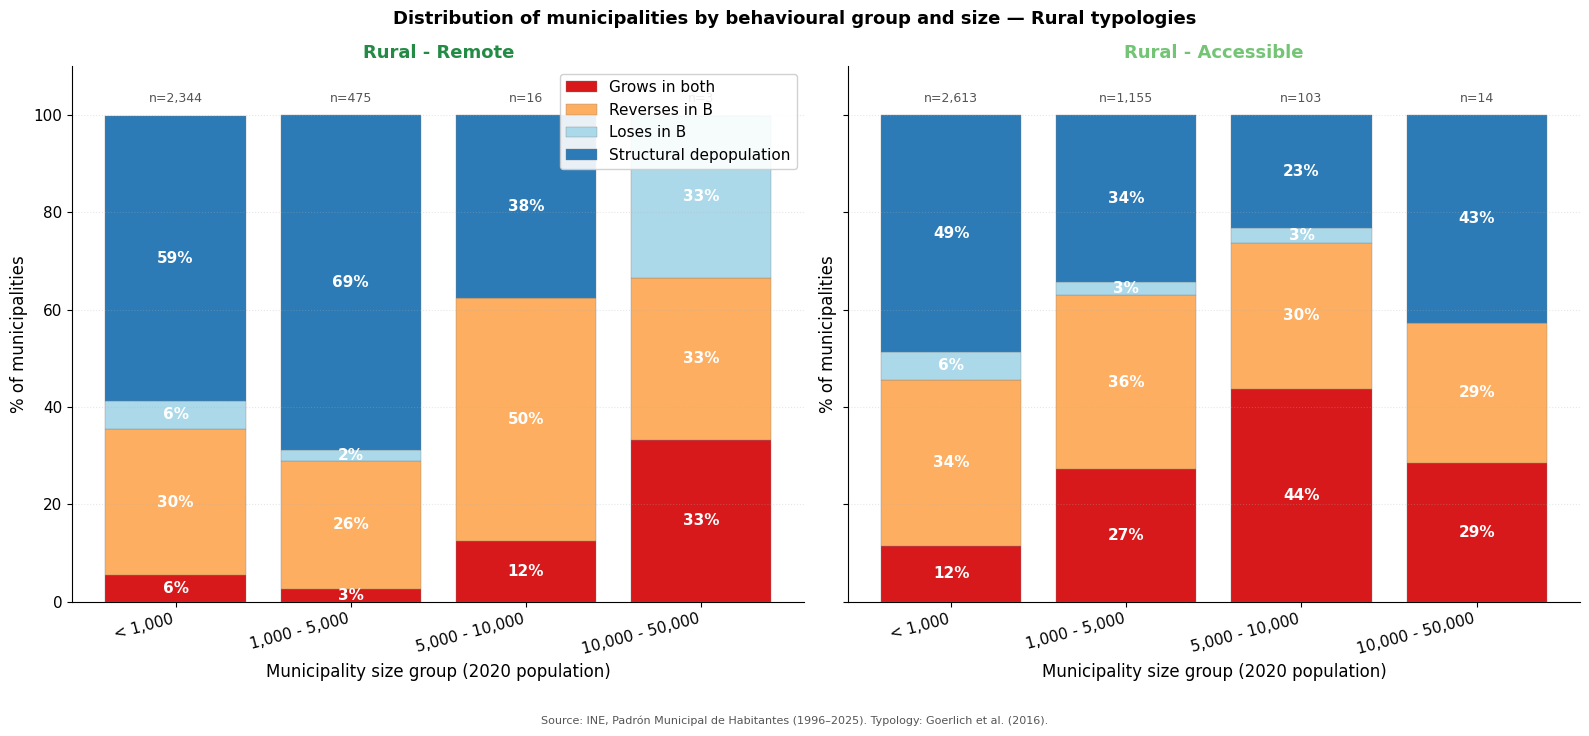

Saved → p3_fig5_size_group_stacked_en.png


In [19]:
# --- Figure 5: behavioural group distribution by size group — rural types ---
# Complements Figure 2 (by typology) with the size dimension.
# Restricted to Rural Remoto and Rural Accesible.

FIG5_LABELS = {
    'title'  : 'Distribution of municipalities by behavioural group and size — Rural typologies',
    'xlabel' : 'Municipality size group (2020 population)',
    'ylabel' : '% of municipalities',
    'source' : 'Source: INE, Padrón Municipal de Habitantes (1996–2025). Typology: Goerlich et al. (2016).',
}

SIZE_ORDER_PLOT = ['< 1,000', '1,000 - 5,000', '5,000 - 10,000', '10,000 - 50,000']

def fig5_size_group_stacked(df_rural):
    labs = FIG5_LABELS
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

    for ax, typ in zip(axes, RURAL_TYPES):
        sub = df_rural[df_rural['tipo_goerlich'] == typ].copy()

        # Build % matrix by size group
        size_pct = pd.crosstab(
            sub['size_group'],
            sub['behavioural_group'],
            normalize='index'
        ).mul(100).round(1)

        # Keep only size groups present and in order
        size_rows = [s for s in SIZE_ORDER_PLOT if s in size_pct.index]
        size_pct  = size_pct.loc[size_rows]

        # Keep only valid groups
        groups = [g for g in GROUP_ORDER if g in size_pct.columns]

        bottom = np.zeros(len(size_pct))
        for group in groups:
            vals = size_pct[group].values
            ax.bar(range(len(size_pct)), vals,
                   bottom=bottom,
                   color=GROUP_COLORS[group],
                   label=group,
                   edgecolor='grey', linewidth=0.25)
            for j, (v, b) in enumerate(zip(vals, bottom)):
                if v > 0:
                    ax.text(j, b + v / 2, f'{v:.0f}%',
                            ha='center', va='center',
                            fontsize=11, fontweight='bold', color='white')
            bottom += vals

        # Annotate n per size group
        for j, sg in enumerate(size_rows):
            n_sg = len(sub[sub['size_group'] == sg])
            ax.text(j, 102, f'n={n_sg:,}',
                    ha='center', va='bottom', fontsize=9, color='#555555')

        ax.set_xticks(range(len(size_pct)))
        ax.set_xticklabels(size_rows, rotation=15, ha='right', fontsize=11)
        ax.set_ylabel(labs['ylabel'], fontsize=12)
        ax.set_xlabel(labs['xlabel'], fontsize=12)
        ax.set_ylim(0, 110)
        ax.set_title(f'{TYPOLOGY_TITLES_EN[typ]}', fontsize=13, fontweight='bold',
                     color=GOERLICH_COLORS[typ])
        ax.tick_params(axis='y', labelsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
        if ax == axes[0]:
            ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

    fig.suptitle(labs['title'], fontsize=13, fontweight='bold')
    fig.text(0.5, -0.04, labs['source'],
             ha='center', fontsize=8, color='#555555')
    plt.tight_layout()

    fp = FIGURES_DIR / 'p3_fig5_size_group_stacked_en.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fp.name}')

fig5_size_group_stacked(df_rural)

In [20]:
# --- Size group distribution within behavioural groups — rural typologies ---
# Quick descriptive table to inform results text.
# Shows N and % of each size group within each behavioural group × typology.

for typ in RURAL_TYPES:
    sub = df[df['tipo_goerlich'] == typ].copy()
    print(f'\n{"="*70}')
    print(f'{TYPOLOGY_TITLES_EN[typ]} — size group by behavioural group')
    print(f'{"="*70}')

    for group in GROUP_ORDER:
        sg = sub[sub['behavioural_group'] == group]
        if len(sg) == 0:
            continue
        dist     = sg['size_group'].value_counts()
        dist_pct = (dist / len(sg) * 100).round(1)
        tbl      = pd.DataFrame({'n': dist, '%': dist_pct})
        # Sort by SIZE_ORDER
        tbl = tbl.reindex([s for s in SIZE_ORDER_PLOT if s in tbl.index])
        print(f'\n  {group} (n={len(sg):,})')
        print(tbl.to_string())

    # Summary: % reverters by size group
    print(f'\n  --- % "Reverses in B" by size group ---')
    for sg_label in SIZE_ORDER_PLOT:
        sg_sub = sub[sub['size_group'] == sg_label]
        if len(sg_sub) == 0:
            continue
        n_rev = (sg_sub['behavioural_group'] == 'Reverses in B').sum()
        n_tot = len(sg_sub)
        print(f'  {sg_label:20s}: {n_rev:4d} / {n_tot:4d}  ({n_rev/n_tot*100:.1f}%)')


Rural - Remote — size group by behavioural group

  Grows in both (n=146)
                   n     %
size_group                
< 1,000          130  89.0
1,000 - 5,000     13   8.9
5,000 - 10,000     2   1.4
10,000 - 50,000    1   0.7

  Reverses in B (n=837)
                   n     %
size_group                
< 1,000          704  84.1
1,000 - 5,000    124  14.8
5,000 - 10,000     8   1.0
10,000 - 50,000    1   0.1

  Loses in B (n=149)
                   n     %
size_group                
< 1,000          137  91.9
1,000 - 5,000     11   7.4
10,000 - 50,000    1   0.7

  Structural depopulation (n=1,705)
                   n     %
size_group                
< 1,000         1373  80.5
1,000 - 5,000    326  19.1
5,000 - 10,000     6   0.4

  --- % "Reverses in B" by size group ---
  < 1,000             :  704 / 2344  (30.0%)
  1,000 - 5,000       :  124 /  475  (26.1%)
  5,000 - 10,000      :    8 /   16  (50.0%)
  10,000 - 50,000     :    1 /    3  (33.3%)

Rural - Accessible — si

---
## 5 · Export outputs

In [21]:
# --- Export behavioural matrix ---------------------------------------
out_matrix = DEMO_DERIV / 'p3_behavioural_matrix.csv'

export_cols = [
    'Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name',
    'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name',
    'tipo_goerlich', 'size_group', 'Pop_ref',
    'pop_start_A', 'pop_end_A', 'var_acum_pct_A', 'var_anual_media_pct_A',
    'pop_start_B', 'pop_end_B', 'var_acum_pct_B', 'var_anual_media_pct_B',
    'behavioural_group',
]

df[export_cols].to_csv(
    out_matrix, sep=';', encoding='utf-8-sig', index=False
)
print(f'Exported: {out_matrix.name}  ({len(df):,} rows, {len(export_cols)} cols)')

Exported: p3_behavioural_matrix.csv  (8,132 rows, 20 cols)


In [22]:
# --- Export matrix summary (cross-tabulation) ------------------------
out_summary = DEMO_DERIV / 'p3_matrix_summary.csv'

matrix_export = matrix_n.copy()
for g in GROUP_ORDER:
    if g in matrix_pct.columns:
        matrix_export[f'{g}_pct'] = matrix_pct[g].reindex(matrix_export.index)

matrix_export.to_csv(out_summary, sep=';', encoding='utf-8-sig')
print(f'Exported: {out_summary.name}')
print()
print('=== Final matrix ===')
print(matrix_export)

Exported: p3_matrix_summary.csv

=== Final matrix ===
behavioural_group     Grows in both  Reverses in B  Loses in B  \
tipo_goerlich                                                    
Urbano - Cerrado                 92             52           4   
Urbano - Abierto                 47             19           3   
Intermedio - Cerrado            129             50           3   
Intermedio - Abierto            382            348          28   
Rural - Accesible               661           1338         184   
Rural - Remoto                  146            837         149   
All                            1457           2644         371   

behavioural_group     Structural depopulation   All  Grows in both_pct  \
tipo_goerlich                                                            
Urbano - Cerrado                           15   163               56.4   
Urbano - Abierto                           13    82               57.3   
Intermedio - Cerrado                        8   190    

In [23]:
# --- Export top-growing rural municipalities -------------------------
# All rural municipalities with positive var_acum_pct in Period A or B,
# sorted by typology then by var_acum_pct_B descending.

out_top = DEMO_DERIV / 'p3_top_growing_rural.csv'

top_growing = (
    df_rural[
        (df_rural['var_acum_pct_B'] > 0) | (df_rural['var_acum_pct_A'] > 0)
    ]
    [export_cols]
    .sort_values(['tipo_goerlich', 'var_acum_pct_B'], ascending=[True, False])
    .reset_index(drop=True)
)

top_growing.to_csv(out_top, sep=';', encoding='utf-8-sig', index=False)
print(f'Exported: {out_top.name}  ({len(top_growing):,} rows)')
print()
print('=== Summary by typology ===')
summary = top_growing.groupby('tipo_goerlich').agg(
    n_total      =('Mun_Code', 'count'),
    n_growing_A  =('var_acum_pct_A', lambda x: (x > 0).sum()),
    n_growing_B  =('var_acum_pct_B', lambda x: (x > 0).sum()),
    n_growing_both=('behavioural_group', lambda x: (x == 'Grows in both').sum()),
    n_reverses_B  =('behavioural_group', lambda x: (x == 'Reverses in B').sum()),
)
print(summary)

Exported: p3_top_growing_rural.csv  (3,207 rows)

=== Summary by typology ===
                   n_total  n_growing_A  n_growing_B  n_growing_both  \
tipo_goerlich                                                          
Rural - Accesible     2131          812         1945             660   
Rural - Remoto        1076          270          933             145   

                   n_reverses_B  
tipo_goerlich                    
Rural - Accesible          1296  
Rural - Remoto              794  


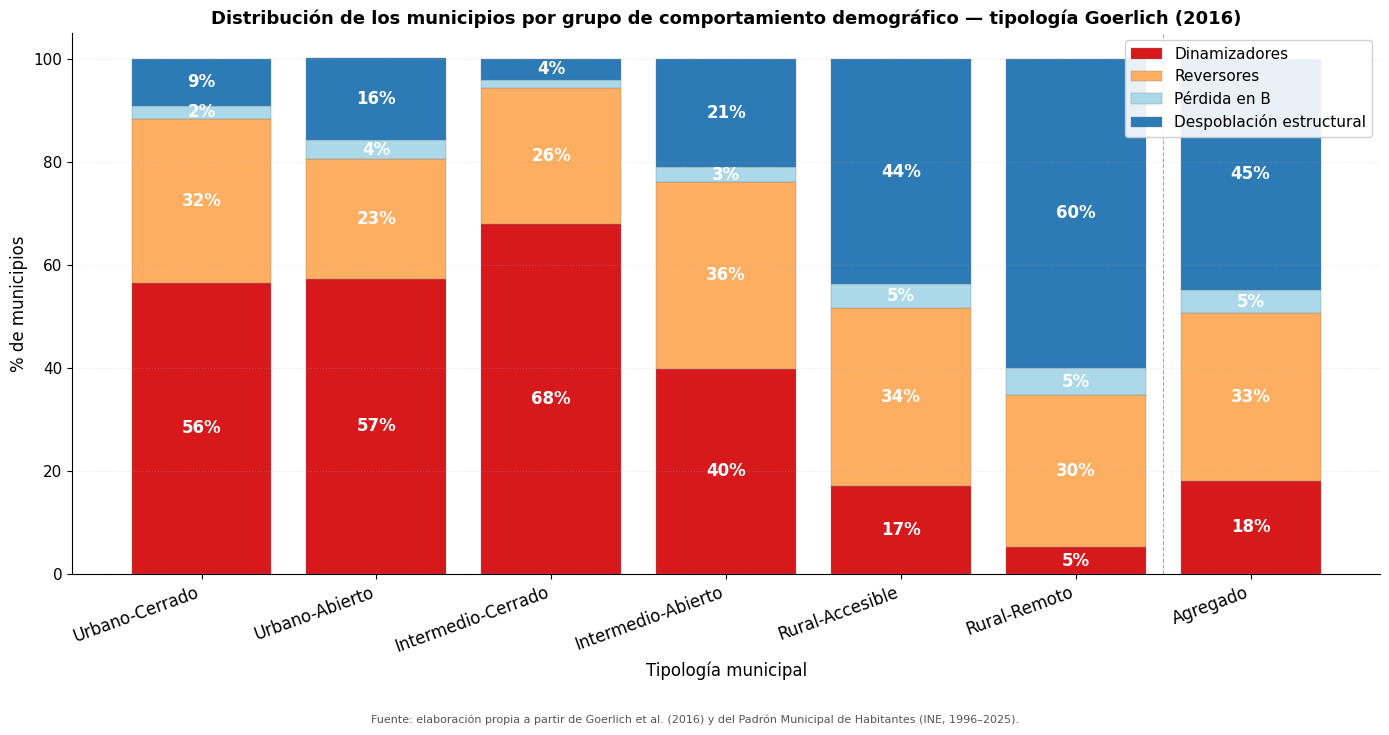

Guardado → p3_fig2_matrix_stacked_es.png


In [24]:
# =============================================================================
# FIGURA 2 — Versión en castellano
# Distribución de municipios por grupo de comportamiento demográfico
# según tipología Goerlich (2016)
# =============================================================================

TYPOLOGY_TITLES_ES = {
    'Urbano - Cerrado'     : 'Urbano-Cerrado',
    'Urbano - Abierto'     : 'Urbano-Abierto',
    'Intermedio - Cerrado' : 'Intermedio-Cerrado',
    'Intermedio - Abierto' : 'Intermedio-Abierto',
    'Rural - Accesible'    : 'Rural-Accesible',
    'Rural - Remoto'       : 'Rural-Remoto',
}

GROUP_LABELS_ES = {
    'Grows in both'          : 'Dinamizadores',
    'Reverses in B'          : 'Reversores',
    'Loses in B'             : 'Pérdida en B',
    'Structural depopulation': 'Despoblación estructural',
}

FIG2_LABELS_ES = {
    'title'     : 'Distribución de los municipios por grupo de comportamiento demográfico — tipología Goerlich (2016)',
    'xlabel'    : 'Tipología municipal',
    'ylabel'    : '% de municipios',
    'source'    : 'Fuente: elaboración propia a partir de Goerlich et al. (2016) y del Padrón Municipal de Habitantes (INE, 1996–2025).',
    'agg_label' : 'Agregado',
}

# ── Columna agregada ponderada — excluir fila 'All' de matrix_n ─────────────
matrix_n_clean = matrix_n.drop(index='All', errors='ignore')[
    [g for g in GROUP_ORDER if g in matrix_n.columns]
]
n_total_es = matrix_n_clean.sum(axis=1)
agg_row_es = (matrix_n_clean.div(n_total_es, axis=0) * 100).mul(
              n_total_es, axis=0).sum() / n_total_es.sum()
agg_df_es  = pd.DataFrame(agg_row_es).T
agg_df_es.index = [FIG2_LABELS_ES['agg_label']]
matrix_plot_es = pd.concat([matrix_pct, agg_df_es])

xticklabels_es = [TYPOLOGY_TITLES_ES[t] for t in matrix_pct.index] + [FIG2_LABELS_ES['agg_label']]

fig, ax = plt.subplots(figsize=(14, 7))
bottom  = np.zeros(len(matrix_plot_es))

for group in GROUP_ORDER:
    if group not in matrix_plot_es.columns:
        continue
    vals  = matrix_plot_es[group].values
    label = GROUP_LABELS_ES[group]
    ax.bar(range(len(matrix_plot_es)), vals,
           bottom=bottom,
           color=GROUP_COLORS[group],
           label=label,
           edgecolor='grey', linewidth=0.25)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 2:
            ax.text(j, b + v / 2, f'{v:.0f}%',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white')
    bottom += vals

# Línea separadora antes de Agregado
ax.axvline(x=len(matrix_pct) - 0.5, color='#aaaaaa',
           linestyle='--', linewidth=0.8)

ax.set_xticks(range(len(matrix_plot_es)))
ax.set_xticklabels(xticklabels_es, rotation=20, ha='right', fontsize=12)
ax.set_ylabel(FIG2_LABELS_ES['ylabel'], fontsize=12)
ax.set_xlabel(FIG2_LABELS_ES['xlabel'], fontsize=12)
ax.set_ylim(0, 105)
ax.set_title(FIG2_LABELS_ES['title'], fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(axis='y', linestyle=':', alpha=0.3)
ax.tick_params(axis='y', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
fig.text(0.5, -0.04, FIG2_LABELS_ES['source'],
         ha='center', fontsize=8, color='#555555')
plt.tight_layout()

fp_es = FIGURES_DIR / 'p3_fig2_matrix_stacked_es.png'
plt.savefig(fp_es, dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardado → {fp_es.name}')

---
## 6 · Interpretation notes

**Key findings from this notebook (p3):**

**National overview (Figure 1):**

- All six typologies shift positively from Period A to Period B, confirming T=2018 as a broad structural change across the entire Spanish demographic system.
- The largest shifts between periods are concentrated in the rural strata: Rural-Accessible (+8.9 pp) and Rural-Remote (+9.3 pp), consistent with the counter-urbanisation hypothesis.
- Rural-Accessible achieves full reversal (−7.4% → +1.5%); Rural-Remote shows a strong partial reversal (−12.1% → −2.8%) — sustained depopulation continues but at a sharply reduced rate.
- The share of growing municipalities doubles or triples across rural strata between periods: Rural-Remote from 9.5% to 32.9%, Rural-Accessible from 20.9% to 50.1%.

**Behavioural matrix (Figure 2):**

- 'Structural depopulation' dominates both rural typologies: 60.1% of Rural-Remote and 43.7% of Rural-Accessible municipalities decline in both periods.
- 'Reverses in B' is the largest dynamic group in both rural typologies: 29.5% of Rural-Remote (n=837) and 34.5% of Rural-Accessible (n=1,338). These are municipalities that crossed from decline to growth after T=2018 — the core empirical signal of Paper 1.
- 'Grows in both' is rare in Rural-Remote (5.1%, n=146) but more common in Rural-Accessible (17.0%, n=661), reflecting structural accessibility advantages.
- Urban and Intermediate typologies are dominated by 'Grows in both' (56–68%), confirming that the reversal pattern is specific to rural strata.

**Rural focus (Figures 3–4):**

- Reverters in Rural-Remote (n=837) have a median Period B growth of +6.9% and a median population of 221 inhabitants — small, isolated municipalities showing a genuine demographic turnaround.
- Reverters in Rural-Accessible (n=1,338) show a similar median Period B growth of +6.8% but a notably larger median population (507 hab.), consistent with the greater size diversity of this typology.
- The reversal signal is not concentrated in the smallest municipalities: within Rural-Accessible, 'Reverses in B' represents ~34–36% of municipalities across all size groups from <1,000 to 5,000–10,000 inhabitants. In Rural-Remote the pattern is similar (~26–33%), with a small sample anomaly in the 5,000–10,000 group (n=16).
- The top-growing municipalities in Period B are concentrated in Castilla y León, Castilla-La Mancha, Aragón and Madrid province. Several Rural-Remote top growers (La Hiruela, Horcajo de la Sierra-Aoslos, Puebla de la Sierra, Robregordo, Madarcos) belong to the Lozoya-Somosierra comarca (Madrid) — likely peri-urbanisation rather than counter-urbanisation. This is formally controlled in Paso 4 through the spatial outlier criterion: municipalities growing while surrounded by declining neighbours.
- Rural-Accessible top growers in Period B include several Campiña municipalities (Guadalajara) also within Madrid commuting distance — same caveat applies.